# **Drug Response Classification using Support Vector Machine**

The objective is to classify whether a patient will show a positive response to a drug or not using the Support Vector Machine algorithm.

# **Importing  Required Libraries**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [21]:
df =pd.read_csv("/content/drive/MyDrive/ASSIGNMENTS/SVM/Pharma_Industry.csv")
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


# **Data Exploration**

In [22]:
df.shape

(500, 6)

In [23]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

In [24]:
df.dtypes

,0
Drug Dosage (mg),float64
Systolic Blood Pressure (mmHg),float64
Heart Rate (BPM),float64
Liver Toxicity Index (U/L),float64
Blood Glucose Level (mg/dL),float64
Drug Response,int64


In [25]:
df.isnull().sum()

,0
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0


In [26]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


**Explaination**
The shape shows the number of rows and columns. The data types help us understand whether the columns are numerical or categorical. Missing value checking is important because missing data can affect model performance &basic statistics.

# **Class Distribution**

Drug Response
1    260
0    240
Name: count, dtype: int64


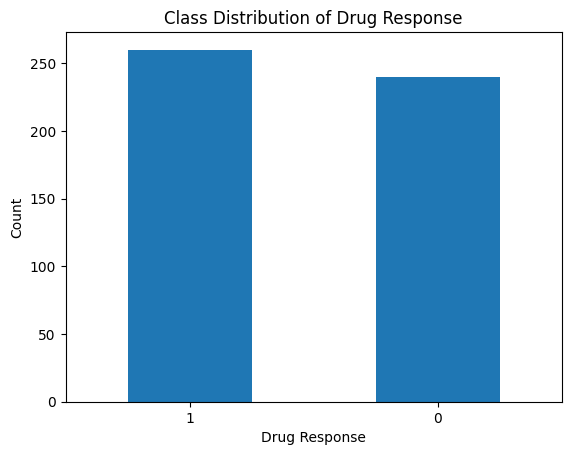

In [27]:
print(df["Drug Response"].value_counts())

df["Drug Response"].value_counts().plot(kind="bar")
plt.title("Class Distribution of Drug Response")
plt.xlabel("Drug Response")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

**Explanation:**
This shows how many records belong to class 0 and class 1.The bar chart shows the distribution of the target variable. It helps us understand whether the dataset is balanced or imbalanced. A balanced dataset has almost equal records for both classes.

# **Feature Distribution using Histograms**

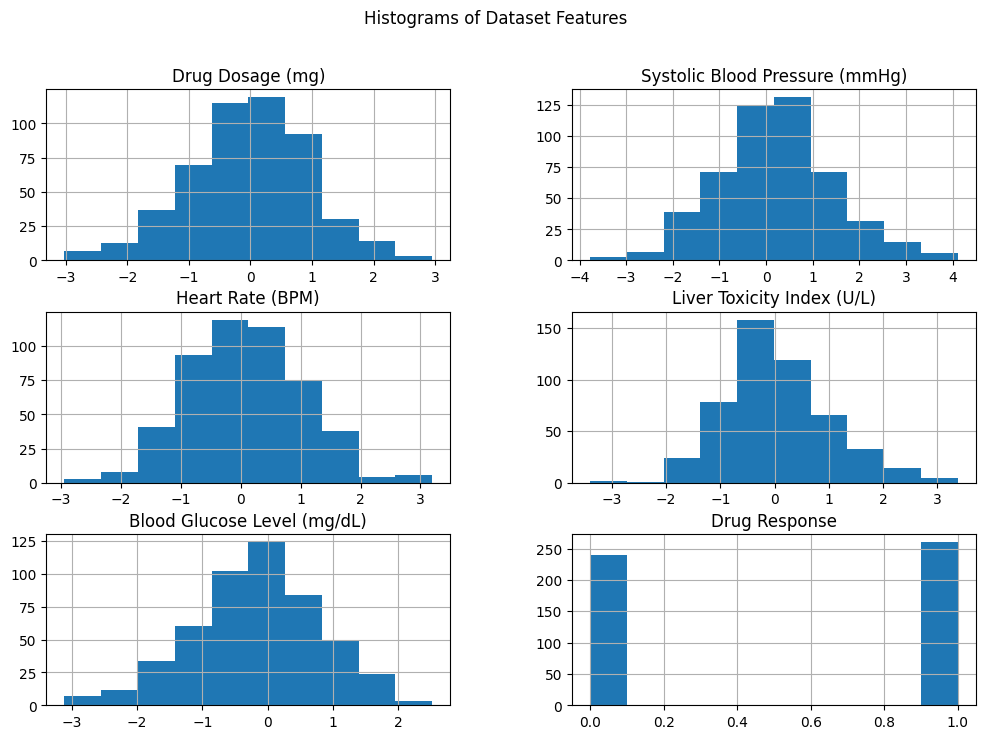

In [28]:
df.hist(figsize=(12, 8))
plt.suptitle("Histograms of Dataset Features")
plt.show()

The histograms show the distribution pattern of each numerical column. It help's us to understand whether the data is normally distributed or spread differently.

# **Box Plots**

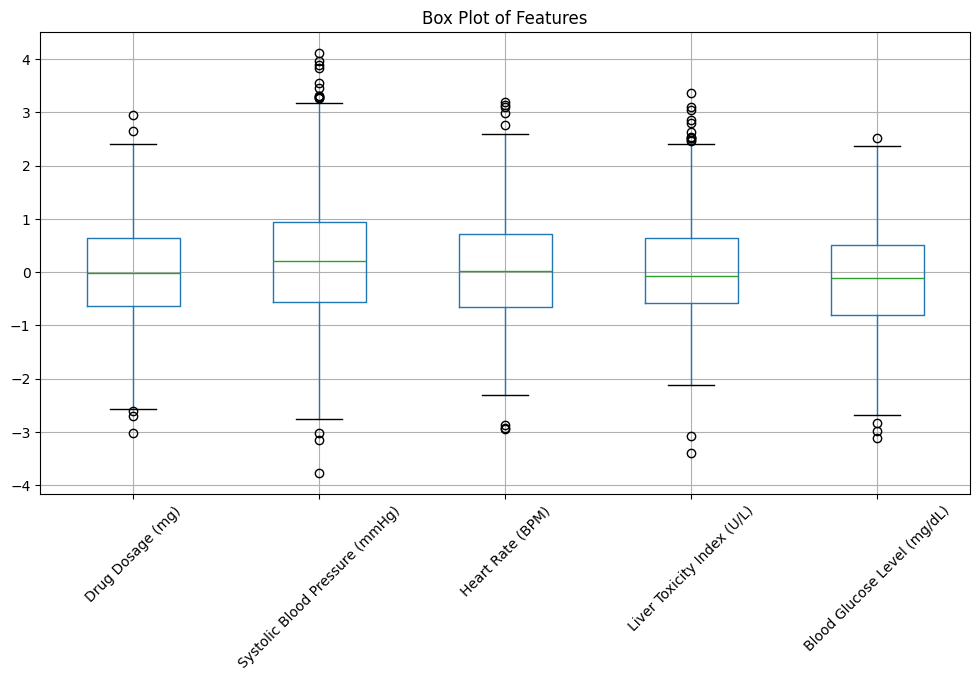

In [29]:
features = df.drop("Drug Response", axis=1).columns

plt.figure(figsize=(12, 6))
df[features].boxplot()
plt.title("Box Plot of Features")
plt.xticks(rotation=45)
plt.show()

Explanation:
Box plots help us check the spread of data and possible outliers.The box plot shows the range, median, and possible outliers in the dataset. Outliers are values that are very different from the normal range of data.

# **Correlation Analysis**

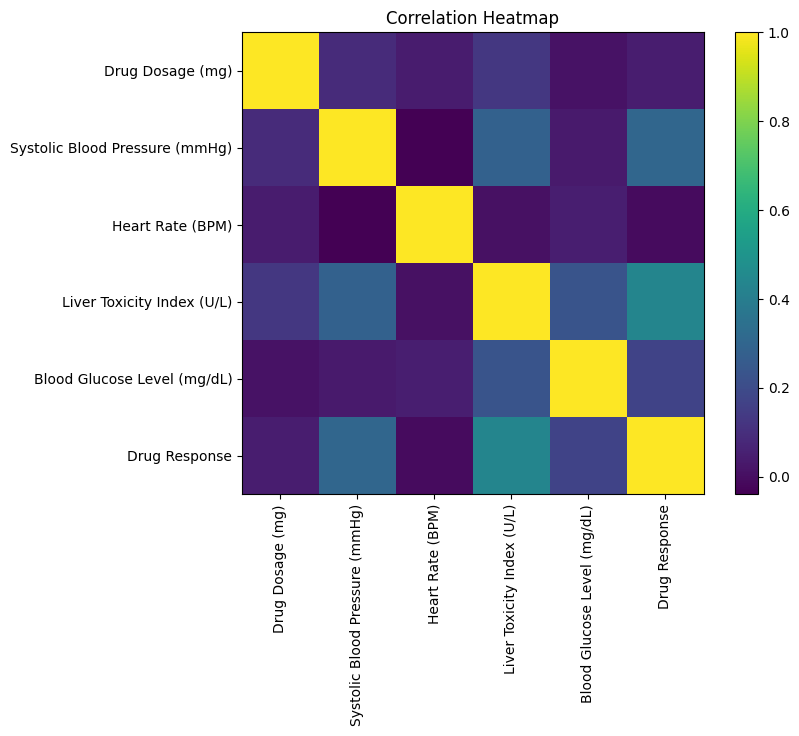

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
Drug Dosage (mg),1.000000,0.090618,0.040571,0.128127,0.012434,0.043457
Systolic Blood Pressure (mmHg),0.090618,1.000000,-0.039195,0.283672,0.037228,0.305226
Heart Rate (BPM),0.040571,-0.039195,1.000000,0.005818,0.049897,-0.009715
Liver Toxicity Index (U/L),0.128127,0.283672,0.005818,1.000000,0.229474,0.434722
Blood Glucose Level (mg/dL),0.012434,0.037228,0.049897,0.229474,1.000000,0.169342
Drug Response,0.043457,0.305226,-0.009715,0.434722,0.169342,1.000000


In [30]:
corr = df.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

corr

**Explanation:**
Correlation shows the relationship between numerical features.The correlation heatmap shows how strongly one feature is related to another feature. Values close to 1 show a strong positive relationship, values close to -1 show a strong negative relationship, and values near 0 show weak relation.

# **Scatter Matrix**

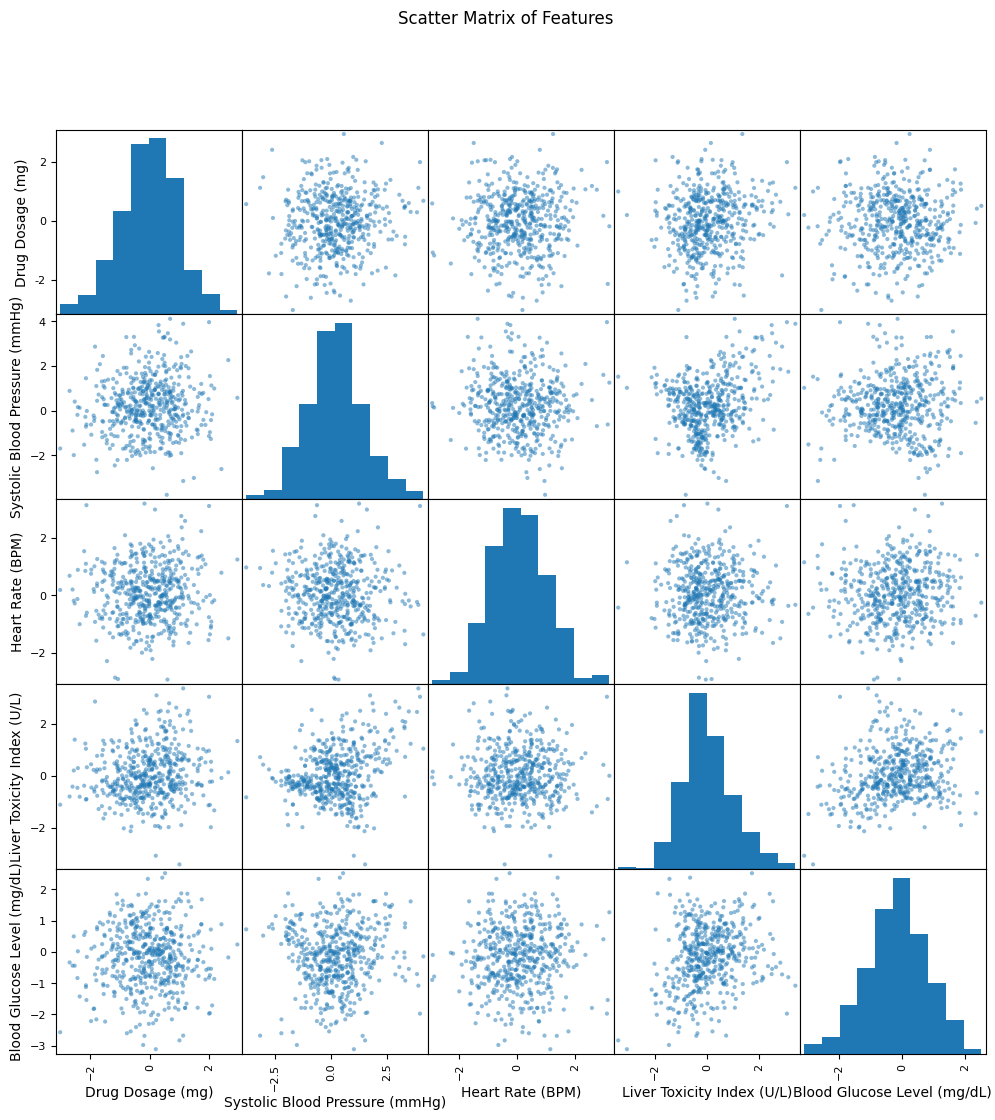

In [31]:
scatter_matrix(df[features], figsize=(12, 12), diagonal="hist")
plt.suptitle("Scatter Matrix of Features")
plt.show()

**Explanation:**
Scatter matrix helps us see pairwise relationships between features.The scatter matrix shows relationships between different feature pairs. It helps us visually check if any two features show clear patterns.

# **Data Preprocessing & Train Test split**

In [32]:
X = df.drop("Drug Response", axis=1)
y = df["Drug Response"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (400, 5)
Testing data shape: (100, 5)


**Explanation:**
In this dataset, all input columns are numerical, so encoding is not required. We split the dataset into training and testing parts and scale the features.The target column is separated from the input features. The dataset is divided into training and testing data. Feature scaling is applied because SVM performs better when all features are on a similar scale.

# **SVM Classifier**

In [33]:
svm_model = SVC(kernel="rbf", C=1, gamma="scale", random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.77
Precision: 0.7543859649122807
Recall: 0.8269230769230769
F1 Score: 0.7889908256880734

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.71      0.75        48
           1       0.75      0.83      0.79        52

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



Explanation:
Here I train a Support Vector Machine model using the RBF kernel.The SVM model is trained using the training data and tested on the testing data. Accuracy, precision, recall, and F1-score are used to evaluate model performance.

# **Confusion Matrix**

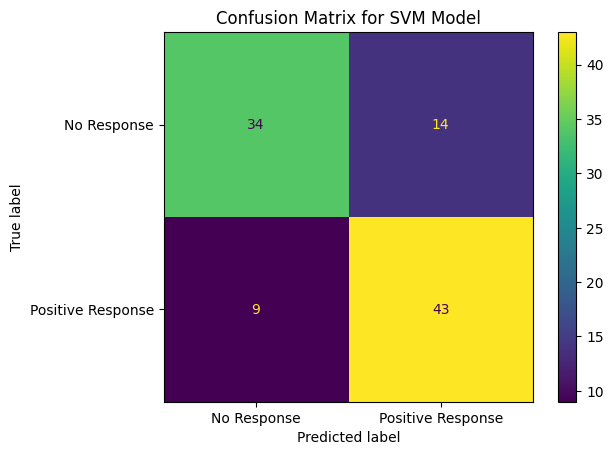

In [34]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Response", "Positive Response"]
)

disp.plot()
plt.title("Confusion Matrix for SVM Model")
plt.show()


**Explanation:**
Confusion matrix shows correct and incorrect predictions.The confusion matrix shows how many values were correctly and incorrectly classified. It compares actual values with predicted values.

# **Visualization of Classification Results**

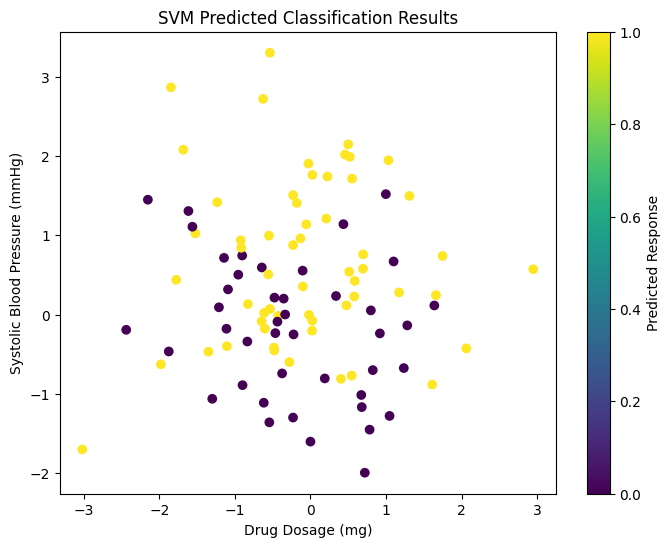

In [35]:
result_df = X_test.copy()
result_df["Actual Response"] = y_test.values
result_df["Predicted Response"] = y_pred

plt.figure(figsize=(8, 6))
plt.scatter(
    result_df["Drug Dosage (mg)"],
    result_df["Systolic Blood Pressure (mmHg)"],
    c=result_df["Predicted Response"]
)

plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Systolic Blood Pressure (mmHg)")
plt.title("SVM Predicted Classification Results")
plt.colorbar(label="Predicted Response")
plt.show()

**Explanation:**
This plot shows predicted classes using two features.This scatter plot shows the predicted drug response using drug dosage and systolic blood pressure. Different colors represent different predicted classes.

# **Parameter Tuning using GridSearchCV**

In [36]:
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "poly", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)

best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test_scaled)

print("\nTest Accuracy after Tuning:", accuracy_score(y_test, best_pred))
print("\nClassification Report after Tuning:")
print(classification_report(y_test, best_pred))

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross Validation Accuracy: 0.7525000000000001

Test Accuracy after Tuning: 0.77

Classification Report after Tuning:
              precision    recall  f1-score   support

           0       0.79      0.71      0.75        48
           1       0.75      0.83      0.79        52

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



**Explanation:**
Here we test different values of C, kernel, and gamma to find the best SVM model.GridSearchCV checks multiple parameter combinations and selects the best one based on accuracy. This improves model performance by finding suitable hyperparameters.

# **Comparison of Different SVM Kernels**

In [37]:
kernels = ["linear", "poly", "rbf"]
results = []

for kernel in kernels:
    model = SVC(kernel=kernel, C=1, gamma="scale", random_state=42)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    results.append({
        "Kernel": kernel,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
results_df

,Kernel,Accuracy,Precision,Recall,F1 Score
0,linear,0.72,0.760870,0.673077,0.714286
1,poly,0.65,0.666667,0.653846,0.660194
2,rbf,0.77,0.754386,0.826923,0.788991


**Explanation:**
Here I compare Linear, Polynomial, and RBF kernels.

# **Kernel Comparison Graph**

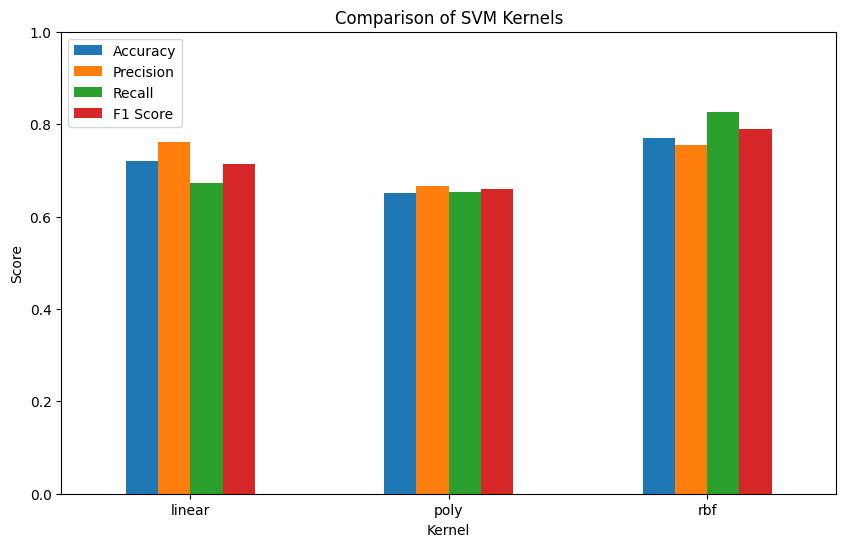

In [38]:
results_df.set_index("Kernel")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of SVM Kernels")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

**Explanation:**
This graph compares the performance of different SVM kernels.The bar chart compares accuracy, precision, recall, and F1-score for different kernels. The kernel with higher scores performs better for this dataset.

# **Final Analysis**

Support Vector Machine was used to classify drug response into two classes: No Response and Positive Response. The dataset was first explored using basic statistics, histograms, box plots, correlation heatmap, and scatter matrix. After that, the data was split into training and testing sets.

Feature scaling was applied because SVM is sensitive to feature values. A basic SVM model was trained using the RBF kernel. The model was evaluated using accuracy, precision, recall, F1-score, classification report, and confusion matrix.

After parameter tuning using GridSearchCV, different SVM kernels were compared. The performance of linear, polynomial, and RBF kernels was checked. Based on the comparison, the best-performing kernel can be selected for final prediction.

**Strengths of SVM**

SVM works well for classification problems. It can handle both linear and non-linear data using different kernels. It gives good results when features are properly scaled.

**Weaknesses of SVM**

SVM requires feature scaling. Its performance depends on correct parameter selection. It can also become slow when the dataset is very large.

**Practical Use**

In the pharmaceutical industry, SVM can help predict whether a patient will respond positively to a drug. This can support clinical trials and personalized medicine by helping doctors and researchers make better decisions.